# 03 — Model Building, Tuning & Evaluation

This notebook builds and evaluates **4 models** for customer churn prediction.  
Each model goes through:
1. Baseline training + cross-validation  
2. Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)  
3. Threshold tuning (optimise for best F1 or Recall)  
4. Final evaluation on test set  

**Models:** Logistic Regression · Random Forest · Neural Network · XGBoost

## 1. Import Libraries

In [1]:
!pip install scikeras xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import (
    train_test_split, cross_validate,
    StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, precision_recall_curve, roc_curve
)

# XGBoost
from xgboost import XGBClassifier

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier

sns.set_theme(style='whitegrid')
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.19.0


## 2. Load Dataset

In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/linda-bsharat/telco-customer-churn-prediction"
    "/refs/heads/main/data/telco_customer_data_cleaned.csv"
)
print(f'Shape: {df.shape}')
df.head()

Shape: (67157, 26)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
0,1,0,0,1,3.0,1,2,0,0,0,...,205.83,1,False,False,False,True,1,0,68.61,1
1,1,1,1,0,2.0,1,2,1,0,0,...,46.30,0,True,False,False,False,1,0,23.15,2
2,0,0,0,0,42.0,1,2,1,0,1,...,1790.46,1,False,False,True,False,0,0,42.63,4
3,0,0,0,1,40.0,1,2,2,0,0,...,3001.60,0,False,False,True,False,0,0,75.04,2
4,1,1,1,1,17.0,1,1,2,1,0,...,380.46,1,False,False,True,False,0,0,22.38,3


## 3. Features & Target

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'Features: {X.shape}')
print(f'Target  : {y.shape}')
print(f'\nChurn distribution:')
print(y.value_counts(normalize=True).round(3))

Features: (67157, 25)
Target  : (67157,)

Churn distribution:
Churn
0    0.531
1    0.469
Name: proportion, dtype: float64


## 4. Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 53,725 | Test: 13,432


## 5. Helper Functions

Reusable utilities used across all models:
- `find_best_threshold()` — scans thresholds and picks the one with best F1
- `evaluate_model()` — prints metrics and plots confusion matrix + ROC curve
- `plot_threshold_analysis()` — visualises Precision / Recall / F1 vs threshold

In [5]:
# ──────────────────────────────────────────────────────────────
# find_best_threshold: scans 0.01–0.99, returns threshold with
# the highest F1 score on the provided probability scores
# ──────────────────────────────────────────────────────────────
def find_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.01, 1.0, 0.01)
    best_thresh, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    return best_thresh, best_f1


# ──────────────────────────────────────────────────────────────
# plot_threshold_analysis: shows how Precision, Recall and F1
# change as the decision threshold shifts
# ──────────────────────────────────────────────────────────────
def plot_threshold_analysis(y_true, y_prob, model_name, best_thresh):
    thresholds = np.arange(0.01, 1.0, 0.01)
    precisions, recalls, f1s = [], [], []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        precisions.append(precision_score(y_true, preds, zero_division=0))
        recalls.append(recall_score(y_true, preds, zero_division=0))
        f1s.append(f1_score(y_true, preds, zero_division=0))

    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, precisions, label='Precision', color='#3498db')
    plt.plot(thresholds, recalls,    label='Recall',    color='#e74c3c')
    plt.plot(thresholds, f1s,        label='F1 Score',  color='#2ecc71', linewidth=2)
    plt.axvline(best_thresh, color='black', linestyle='--',
                label=f'Best Threshold = {best_thresh:.2f}')
    plt.title(f'Threshold Analysis — {model_name}', fontsize=13)
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────
# evaluate_model: prints full metrics, confusion matrix & ROC
# ──────────────────────────────────────────────────────────────
def evaluate_model(model_name, y_true, y_pred, y_prob, color='Blues'):
    print(f'\n{"="*55}')
    print(f'  {model_name} — Final Evaluation')
    print(f'{"="*55}')
    print(f'  Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'  Recall   : {recall_score(y_true, y_pred):.4f}')
    print(f'  F1 Score : {f1_score(y_true, y_pred):.4f}')
    print(f'  AUC      : {roc_auc_score(y_true, y_prob):.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=["No Churn","Churned"])}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=['No Churn', 'Churned'],
                yticklabels=['No Churn', 'Churned'], ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {model_name}', fontsize=12)
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='#9b59b6', lw=2, label=f'AUC = {auc_val:.4f}')
    axes[1].plot([0,1],[0,1], 'k--', alpha=0.4)
    axes[1].set_title(f'ROC Curve — {model_name}', fontsize=12)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

print('Helper functions loaded successfully.')

Helper functions loaded successfully.


---
## 6. Logistic Regression

**Improvement steps:**
1. Baseline + 5-Fold CV
2. Hyperparameter tuning with `GridSearchCV` (`C`, `penalty`, `solver`)
3. Threshold tuning on best model

In [6]:
# ── Step 1: Baseline CV ──────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

lr_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_base_cv = cross_validate(lr_base, X, y, cv=cv, scoring=scoring)

print('=== Logistic Regression — Baseline 5-Fold CV ===')
for m in scoring:
    s = lr_base_cv[f'test_{m}']
    print(f'  {m:<12}: {s.mean():.4f} ± {s.std():.4f}')

=== Logistic Regression — Baseline 5-Fold CV ===
  accuracy    : 0.7687 ± 0.0046
  precision   : 0.6978 ± 0.0043
  recall      : 0.8935 ± 0.0044
  f1          : 0.7836 ± 0.0041
  roc_auc     : 0.7899 ± 0.0064


In [7]:
# ── Step 2: Hyperparameter Tuning ────────────────────────────
lr_param_grid = {
    'model__C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear', 'saga']
}

lr_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    param_grid=lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

lr_grid.fit(X_train, y_train)

print('Best params:', lr_grid.best_params_)
print(f'Best CV F1 : {lr_grid.best_score_:.4f}')

Best params: {'model__C': 0.001, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV F1 : 0.7834


Best Threshold : 0.30
Best F1 (tuned): 0.7844


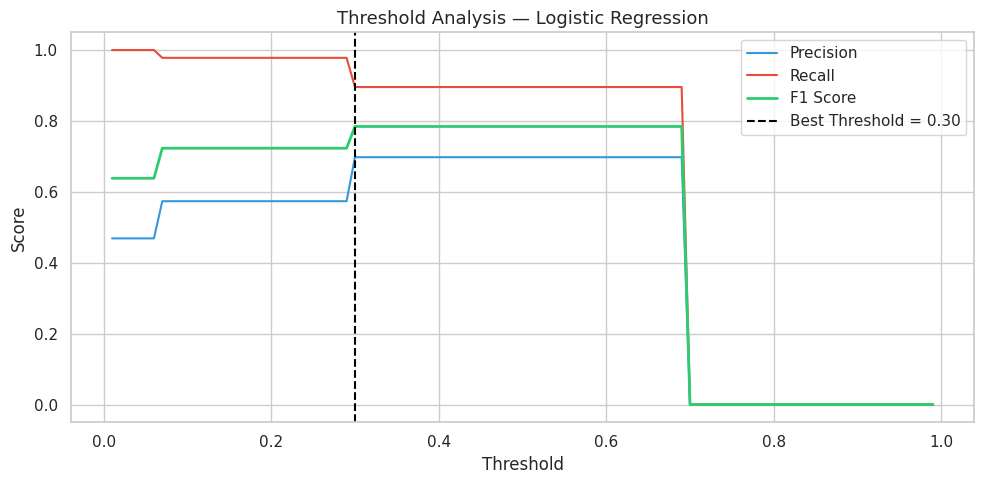

In [8]:
# ── Step 3: Threshold Tuning ─────────────────────────────────
lr_best = lr_grid.best_estimator_
lr_prob  = lr_best.predict_proba(X_test)[:, 1]

lr_best_thresh, lr_best_f1 = find_best_threshold(y_test, lr_prob)
print(f'Best Threshold : {lr_best_thresh:.2f}')
print(f'Best F1 (tuned): {lr_best_f1:.4f}')

plot_threshold_analysis(y_test, lr_prob, 'Logistic Regression', lr_best_thresh)


  Logistic Regression (Tuned) — Final Evaluation
  Accuracy : 0.7692
  Precision: 0.6977
  Recall   : 0.8956
  F1 Score : 0.7844
  AUC      : 0.7881

              precision    recall  f1-score   support

    No Churn       0.88      0.66      0.75      7136
     Churned       0.70      0.90      0.78      6296

    accuracy                           0.77     13432
   macro avg       0.79      0.78      0.77     13432
weighted avg       0.79      0.77      0.77     13432



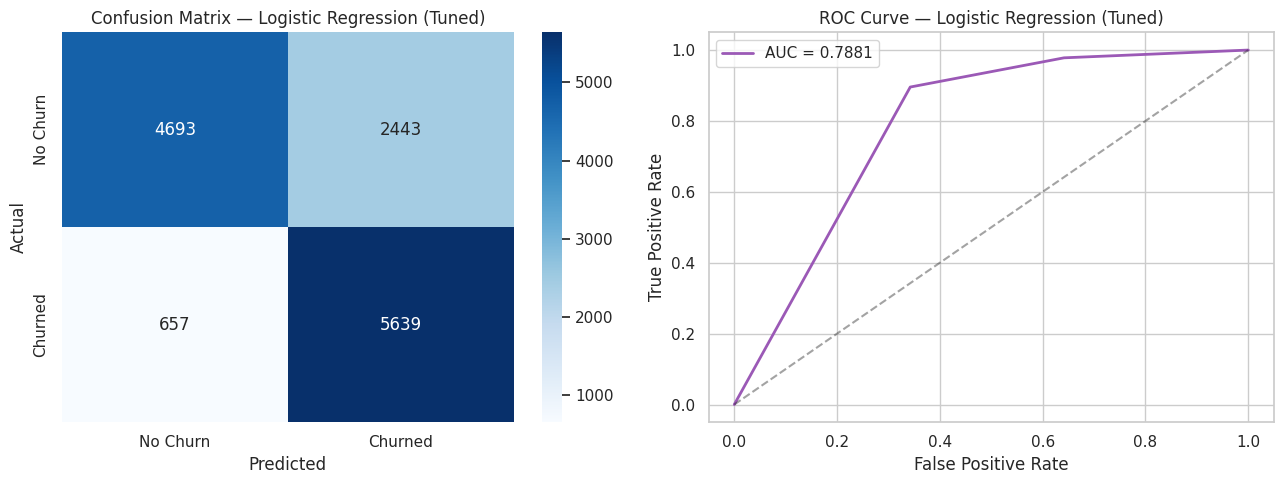

In [9]:
# ── Final Evaluation ─────────────────────────────────────────
lr_pred_tuned = (lr_prob >= lr_best_thresh).astype(int)

evaluate_model('Logistic Regression (Tuned)', y_test, lr_pred_tuned, lr_prob, color='Blues')

# Save results for comparison
lr_results = {
    'Accuracy' : accuracy_score(y_test, lr_pred_tuned),
    'Precision': precision_score(y_test, lr_pred_tuned),
    'Recall'   : recall_score(y_test, lr_pred_tuned),
    'F1'       : f1_score(y_test, lr_pred_tuned),
    'AUC'      : roc_auc_score(y_test, lr_prob),
    'Threshold': lr_best_thresh
}

---
## 7. Random Forest

**Improvement steps:**
1. Baseline + 5-Fold CV
2. Hyperparameter tuning with `RandomizedSearchCV` (n_estimators, max_depth, min_samples, class_weight)
3. Feature importance plot
4. Threshold tuning

In [10]:
# ── Step 1: Baseline CV ──────────────────────────────────────
rf_base = RandomForestClassifier(n_estimators=200, random_state=42)

rf_base_cv = cross_validate(rf_base, X, y, cv=cv, scoring=scoring)

print('=== Random Forest — Baseline 5-Fold CV ===')
for m in scoring:
    s = rf_base_cv[f'test_{m}']
    print(f'  {m:<12}: {s.mean():.4f} ± {s.std():.4f}')

=== Random Forest — Baseline 5-Fold CV ===
  accuracy    : 0.7559 ± 0.0044
  precision   : 0.6968 ± 0.0044
  recall      : 0.8482 ± 0.0048
  f1          : 0.7651 ± 0.0041
  roc_auc     : 0.7879 ± 0.0052


In [12]:
# ── Step 2: Hyperparameter Tuning ────────────────────────────
rf_param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : [None, 'balanced']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

rf_search.fit(X_train, y_train)

print('Best params:', rf_search.best_params_)
print(f'Best CV F1 : {rf_search.best_score_:.4f}')

KeyboardInterrupt: 

In [ ]:
# ── Feature Importance ───────────────────────────────────────
rf_best = rf_search.best_estimator_

feat_imp = pd.Series(rf_best.feature_importances_, index=X.columns)
top15    = feat_imp.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='#2ecc71', edgecolor='white')
plt.title('Random Forest — Top 15 Feature Importances', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# ── Step 3: Threshold Tuning ─────────────────────────────────
rf_prob = rf_best.predict_proba(X_test)[:, 1]

rf_best_thresh, rf_best_f1 = find_best_threshold(y_test, rf_prob)
print(f'Best Threshold : {rf_best_thresh:.2f}')
print(f'Best F1 (tuned): {rf_best_f1:.4f}')

plot_threshold_analysis(y_test, rf_prob, 'Random Forest', rf_best_thresh)

In [ ]:
# ── Final Evaluation ─────────────────────────────────────────
rf_pred_tuned = (rf_prob >= rf_best_thresh).astype(int)

evaluate_model('Random Forest (Tuned)', y_test, rf_pred_tuned, rf_prob, color='Greens')

rf_results = {
    'Accuracy' : accuracy_score(y_test, rf_pred_tuned),
    'Precision': precision_score(y_test, rf_pred_tuned),
    'Recall'   : recall_score(y_test, rf_pred_tuned),
    'F1'       : f1_score(y_test, rf_pred_tuned),
    'AUC'      : roc_auc_score(y_test, rf_prob),
    'Threshold': rf_best_thresh
}

---
## 8. XGBoost

**Improvement steps:**
1. Baseline + 5-Fold CV
2. Handle class imbalance via `scale_pos_weight`
3. Hyperparameter tuning with `RandomizedSearchCV`
4. Threshold tuning

In [ ]:
# ── Step 1: Baseline CV ──────────────────────────────────────
# Handle class imbalance with scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count
print(f'scale_pos_weight = {scale_pos:.2f}  (neg:{neg_count} / pos:{pos_count})')

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos,
    random_state=42,
    verbosity=0
)

xgb_base_cv = cross_validate(xgb_base, X, y, cv=cv, scoring=scoring)

print('\n=== XGBoost — Baseline 5-Fold CV ===')
for m in scoring:
    s = xgb_base_cv[f'test_{m}']
    print(f'  {m:<12}: {s.mean():.4f} ± {s.std():.4f}')

In [ ]:
# ── Step 2: Hyperparameter Tuning ────────────────────────────
xgb_param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 4, 5, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma'           : [0, 0.1, 0.3, 0.5],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],
    'reg_lambda'      : [1, 1.5, 2.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos,
        random_state=42,
        verbosity=0
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

xgb_search.fit(X_train, y_train)

print('Best params:', xgb_search.best_params_)
print(f'Best CV F1 : {xgb_search.best_score_:.4f}')

In [ ]:
# ── Feature Importance ───────────────────────────────────────
xgb_best = xgb_search.best_estimator_

xgb_feat_imp = pd.Series(xgb_best.feature_importances_, index=X.columns)
top15_xgb    = xgb_feat_imp.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
top15_xgb.plot(kind='barh', color='#e67e22', edgecolor='white')
plt.title('XGBoost — Top 15 Feature Importances', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# ── Step 3: Threshold Tuning ─────────────────────────────────
xgb_prob = xgb_best.predict_proba(X_test)[:, 1]

xgb_best_thresh, xgb_best_f1 = find_best_threshold(y_test, xgb_prob)
print(f'Best Threshold : {xgb_best_thresh:.2f}')
print(f'Best F1 (tuned): {xgb_best_f1:.4f}')

plot_threshold_analysis(y_test, xgb_prob, 'XGBoost', xgb_best_thresh)

In [ ]:
# ── Final Evaluation ─────────────────────────────────────────
xgb_pred_tuned = (xgb_prob >= xgb_best_thresh).astype(int)

evaluate_model('XGBoost (Tuned)', y_test, xgb_pred_tuned, xgb_prob, color='Oranges')

xgb_results = {
    'Accuracy' : accuracy_score(y_test, xgb_pred_tuned),
    'Precision': precision_score(y_test, xgb_pred_tuned),
    'Recall'   : recall_score(y_test, xgb_pred_tuned),
    'F1'       : f1_score(y_test, xgb_pred_tuned),
    'AUC'      : roc_auc_score(y_test, xgb_prob),
    'Threshold': xgb_best_thresh
}

---
## 9. Neural Network

**Improvement steps:**
1. Scale features
2. Architecture with BatchNorm + Dropout + class weighting
3. Callbacks: EarlyStopping + ReduceLROnPlateau
4. Training history plot
5. Threshold tuning

In [ ]:
# ── Scale Features ───────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Compute class weight to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f'Class weights: {class_weight_dict}')

In [ ]:
# ── Build Model ──────────────────────────────────────────────
def build_nn(n_features=None):
    if n_features is None:
        n_features = X_train_scaled.shape[1]
    m = Sequential([
        Dense(128, activation='relu', input_shape=(n_features,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.2),

        Dense(1, activation='sigmoid')
    ])
    m.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return m

nn_model = build_nn()
nn_model.summary()

In [ ]:
# ── Train with Callbacks ─────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print(f'Training stopped at epoch {len(history.history["loss"])}')

In [ ]:
# ── Training History ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c')
axes[0].set_title('Loss During Training', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#e67e22')
axes[1].set_title('Accuracy During Training', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── 5-Fold CV for Neural Network ─────────────────────────────
nn_cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KerasClassifier(
        model=build_nn,
        model__n_features=X.shape[1],
        epochs=50,
        batch_size=256,
        verbose=0
    ))
])

nn_cv_results = cross_validate(nn_cv_pipeline, X, y, cv=cv, scoring=scoring)

print('=== Neural Network — 5-Fold CV ===')
for m in scoring:
    s = nn_cv_results[f'test_{m}']
    print(f'  {m:<12}: {s.mean():.4f} ± {s.std():.4f}')

In [ ]:
# ── Threshold Tuning ─────────────────────────────────────────
nn_prob = nn_model.predict(X_test_scaled).flatten()

nn_best_thresh, nn_best_f1 = find_best_threshold(y_test, nn_prob)
print(f'Best Threshold : {nn_best_thresh:.2f}')
print(f'Best F1 (tuned): {nn_best_f1:.4f}')

plot_threshold_analysis(y_test, nn_prob, 'Neural Network', nn_best_thresh)

In [ ]:
# ── Final Evaluation ─────────────────────────────────────────
nn_pred_tuned = (nn_prob >= nn_best_thresh).astype(int)

evaluate_model('Neural Network (Tuned)', y_test, nn_pred_tuned, nn_prob, color='Purples')

nn_results = {
    'Accuracy' : accuracy_score(y_test, nn_pred_tuned),
    'Precision': precision_score(y_test, nn_pred_tuned),
    'Recall'   : recall_score(y_test, nn_pred_tuned),
    'F1'       : f1_score(y_test, nn_pred_tuned),
    'AUC'      : roc_auc_score(y_test, nn_prob),
    'Threshold': nn_best_thresh
}

---
## 10. Final Model Comparison

In [ ]:
# ── Summary Table ────────────────────────────────────────────
comparison = pd.DataFrame({
    'Logistic Regression': lr_results,
    'Random Forest'      : rf_results,
    'XGBoost'            : xgb_results,
    'Neural Network'     : nn_results,
}).T.round(4)

print('=' * 70)
print('FINAL MODEL COMPARISON — After Tuning + Threshold Optimisation')
print('=' * 70)
print(comparison.to_string())
print('=' * 70)

In [ ]:
# ── F1 Score Bar Chart ───────────────────────────────────────
model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'Neural\nNetwork']
f1_scores   = [lr_results['F1'], rf_results['F1'], xgb_results['F1'], nn_results['F1']]
auc_scores  = [lr_results['AUC'], rf_results['AUC'], xgb_results['AUC'], nn_results['AUC']]
colors      = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1
bars = axes[0].bar(model_names, f1_scores, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(0.70, color='red', linestyle='--', alpha=0.7, label='F1 Threshold 0.70')
axes[0].set_title('F1 Score — All Models (Tuned)', fontsize=13)
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.0)
axes[0].legend()

# AUC
bars2 = axes[1].bar(model_names, auc_scores, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, auc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('AUC Score — All Models (Tuned)', fontsize=13)
axes[1].set_ylabel('AUC Score')
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

In [ ]:
# ── All Metrics Grouped Bar Chart ────────────────────────────
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
lr_vals  = [lr_results[m]  for m in metrics_list]
rf_vals  = [rf_results[m]  for m in metrics_list]
xgb_vals = [xgb_results[m] for m in metrics_list]
nn_vals  = [nn_results[m]  for m in metrics_list]

x     = np.arange(len(metrics_list))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - 1.5*width, lr_vals,  width, label='Logistic Regression', color='#3498db')
b2 = ax.bar(x - 0.5*width, rf_vals,  width, label='Random Forest',       color='#2ecc71')
b3 = ax.bar(x + 0.5*width, xgb_vals, width, label='XGBoost',              color='#e67e22')
b4 = ax.bar(x + 1.5*width, nn_vals,  width, label='Neural Network',       color='#9b59b6')

for group in [b1, b2, b3, b4]:
    for bar in group:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=12)
ax.set_ylim(0, 1.1)
ax.axhline(0.70, color='red', linestyle='--', alpha=0.4, label='Threshold 0.70')
ax.set_title('All Metrics — All Models (After Tuning)', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ── ROC Curves — All Models Together ─────────────────────────
plt.figure(figsize=(9, 7))

for name, prob, color in [
    ('Logistic Regression', lr_prob,  '#3498db'),
    ('Random Forest',       rf_prob,  '#2ecc71'),
    ('XGBoost',             xgb_prob, '#e67e22'),
    ('Neural Network',      nn_prob,  '#9b59b6'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={auc_val:.4f})')

plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Random Classifier')
plt.title('ROC Curves — All Models', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ── Final Summary Print ──────────────────────────────────────
print('=' * 75)
print('  FINAL SUMMARY — TUNED MODELS WITH THRESHOLD OPTIMISATION')
print('=' * 75)
print(f'  {"Model":<25} {"Threshold":>10} {"Accuracy":>10} {"F1":>8} {"Recall":>9} {"AUC":>8}')
print('-' * 75)
for name, res in [
    ('Logistic Regression', lr_results),
    ('Random Forest',       rf_results),
    ('XGBoost',             xgb_results),
    ('Neural Network',      nn_results),
]:
    print(f'  {name:<25} {res["Threshold"]:>10.2f} {res["Accuracy"]:>10.4f} '
          f'{res["F1"]:>8.4f} {res["Recall"]:>9.4f} {res["AUC"]:>8.4f}')
print('=' * 75)